# Assignment 3: Linear Models

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression

### **Q1.** Please answer the following questions in your own words.

**1. What makes a model "linear"? "Linear" in what?**

A model is linear when it assumes a linear relationship between feature and target variables - or, in other words, assumes that the model's parameters are linear. For any linear model, it will always be the case that our estimate $\hat{y}$ can be expressed by $\beta_{0} + \sum_i{\beta_{i}X_{i}} + \epsilon $, where $\beta_{0}$ is our intercept and $\beta_{i}$ are our coefficients. 

**2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)**
   
The coefficient for a one-hot-encoded variable represents the expected change in the target variable when a specific category is present (in which case it is recorded as 1) versus when it is not present (in which case it is represented as 0). When we drop a category to avoid the dummy variable trap, the coefficients tell us how far away (on average) each category is from the dropped category.

**3. Can linear regression be used for classification? Explain why, or why not.**
Linear regression returns a continuous value as its result, so it's not able to return a direct classification. However, it can be used to produce continuous values that describe the likelihood of something being one thing or not. For example, if we're trying to see if something is a cat, and we define 1 as absolute cat and 0 as not a cat, our model would return what can be interpreted as a probability of something being a cat. We can use this as a classifier by setting a threshold, like anything over 0.5 is classified one way, and anything below is classified as another. But, linear regression is best used to find the (linear) line of best fit and to predict continuous values, so while it is possible to use it for classification, there are certainly other models better suited to doing so.

**4. What are signs that your linear model is over-fitting?**
   
As with different model types, if the train-test split results in the model performing well on training data but not well on test data, then it is overfitting. For linear models in specific, a model may be overfitted if there aren't enough observations for each parameter added.

**4. Clearly explain multi-colinearity using the two-stage least squares technique.**

Multicolinearity occurs when feature variables are highly correlated with each other and the target variable, resulting in high variance and for the feature variables to essentially cancel each other out (since it's hard for a model to determine where the correlations are originating). To explain this in terms of the two-stage least squares technique: 

Say we have some variables $X_{1}$ and $X_{2}$ who have a multicolinear relationship (alongside the target variable). The goal of 2SLS is to find the origin of causal effects when our feature variables are endogenous (aka correlated with error terms). When variables have this sort of relationship, one of them is called the instrumental variable  (which we will designate as $X_{2}$ since it can act as a proxy for $X_1$). So, the 2SLS technique addresses multicolinearity by 1) regressing the instrumental variable $X_{2}$ on an external instrument (variable outside of our model) and other independent variables, and 2) using the resulting predicted variable $\hat{X_{2}}$ in place of $X_{2}$ to run the original regression and reduce multicolinearity.

**5. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?**

To incorporate nonlinear relationships into a linear regression, you can transform the data to linearize nonlinear relationships (e.g., if there exists an exponential relationship, you can linearize it by taking the log, and from there, perform analysis using a linear regression) or by introducing interaction terms. Outside of a linear regression, you can use other regression methods like a polynomial regression (which isn't a variation upon a linear regression because while the coefficient terms may be linear, the $x_i$ values are not).

**6. What is the interpretation of the slope coefficient in a linear regression?**
   
For any increase by one in a feature variable, the target variable increases/decreases by the slope coefficient (the slope coefficient is the $m$ in the equation $y = mx + b$)

**7. Compare the train/test split and $k$-fold cross validation.**

The train-test split runs the same regression on two chunks of the data, where the model is trained on the 'train' set and then tested on the 'test' set to see if the model doesn't overfit the data. $K$-fold cross validation does something similar (as in, tests a model's accuracy given a chunk of the data) but with $K$-1 different chunks (the remaining fold acts as the 'train' data set). So, as the notes put it, $k$-fold cross validation is like a $k$-way train-test split.

**8.  How is the $k$ in $k$-fold cross validation typically selected?**

$k$ is usually chosen based on how large the dataset is. Generally, a higher $k$ value means higher variance but lower bias, and a lower $k$ means a higher bias but a lower variance. The smaller the dataset, the more helpful it is to choose a larger $k$, but the usual default $k$ values are 5 and 10.

### **Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

In [5]:
q1 = pd.read_csv('./data/Q1_clean.csv')
q1.rename(columns={'Neighbourhood ':'Neighborhood'},inplace=True)
q1.head()

,Price,Review Scores Rating,Neighborhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


**1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.**

In [11]:
# Compute average price + scores by Neighborhood
q1.groupby('Neighborhood')[['Price','Review Scores Rating']].describe()

NameError: name 'q1' is not defined

The borough that is the most expensive on average is Manhattan.

In [12]:
# kdeplot of price
sns.kdeplot(data=q1, x='Price', hue='Neighborhood')
plt.suptitle("Price by Neighborhood")

plt.show()

NameError: name 'q1' is not defined

In [13]:
# kde plot of log price
q1['Log Price'] = np.log(q1['Price'])

sns.kdeplot(data=q1, x='Log Price', hue='Neighborhood')
plt.suptitle("Log Price by Neighborhood")

plt.show()

NameError: name 'q1' is not defined

**2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regression?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?**

In [14]:
pd.get_dummies(q1['Neighborhood']).head()

NameError: name 'q1' is not defined

In [15]:
X_hood = pd.get_dummies(q1['Neighborhood'], dtype='int', drop_first=True)
X_hood.head()

NameError: name 'q1' is not defined

In [16]:
y = q1['Price']

model = LinearRegression()
model = model.fit(X_hood, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

NameError: name 'q1' is not defined

I handled the dummy variable trap by dropping the first category.

The mean of this dropped first category is equal to the model's intercept $\beta_{0}$ (75.276). The estimated coefficients are equal to the conditional group means for each non-dropped category minus $\beta_{0}$ (so, adding each $\beta_{i}$ to $\beta_{0}$ will add up to the corresponding conditional group mean price). 

**3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.**

In [17]:
x = q1['Review Scores Rating'].to_frame()

model = LinearRegression()
model = model.fit(x, y)

print(f"Intercept: {model.intercept_}")
print(f"Slope Coefficient: {model.coef_}")


y_hat = model.predict(x)

plt.scatter(x,y)
plt.plot(x,y_hat, 'r')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

NameError: name 'q1' is not defined

The slope coefficient is 1.0208. This means that for each score increase of 1 point, the price increases by 1.0208 - so there is a positive, almost exactly linear relationship between score and price.

**4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?**

In [18]:
X = pd.concat([x,X_hood], axis = 1)

model_4 = LinearRegression()
model_4 = model.fit(X, y)

print(f'Model intercept: {model_4.intercept_}')
pd.DataFrame({'variable':model_4.feature_names_in_, 'coefficient':model_4.coef_ })

NameError: name 'X_hood' is not defined

The slope coefficient on `Review Scores Rating` increases slightly, from 1.02 to 1.08. The neighborhood averages (reflected by the associated coefficients) don't change very much, with the greatest change being Staten Island's increase from 70.890 to 71.766 (which, given the scale of the price data, isn't a very large change). From this, we can assume that trends of score affect on price and location affect on price hold even when compared against each other.

**5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?**

In [19]:
# i am reading this as implementing the neighborhood and score rating interactions terms? 
X_interactions = X_hood.multiply(q1['Review Scores Rating'], axis=0) # i didn't even know there was a .multiply function until now wow <3

model_5 = LinearRegression(fit_intercept=True)
model_5.fit(X_interactions, y)

print(f'Model intercept: {model_5.intercept_}')
pd.DataFrame({'variable':model_5.feature_names_in_, 'coefficient':model_5.coef_ })

NameError: name 'X_hood' is not defined

The slopes are not similar across neighborhoods. Manhattan has the largest slope coefficient at 1.285, being almost double the 2nd largest slope coefficient at Brooklyn's 0.677 and Queens has the smallest slope coefficient at 0.34. Given the scale of these coefficients, these are very significant differences.

**6. Use cross validation to evaluate the models from parts 4, 5, and 6.**

In [20]:
from sklearn.model_selection import KFold, cross_val_score #assuming we're using k-fold cross validation
from sklearn.metrics import mean_squared_error
# also assuming that this is only referring to the models from Qs 4 and 5 because this is is Q6...

kfold = KFold(n_splits=10, shuffle=True, random_state=100)


neg_scores = cross_val_score(
    model_4, X, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error' 
)
scores = -neg_scores

print("Q4 MODEL:")
print("Fold scores:", scores, '\n')
print("Mean score:", np.mean(scores), '\n')
print("Median score:", np.median(scores), '\n')
print("Std dev:", np.std(scores))

NameError: name 'model_4' is not defined

In [21]:
neg_scores = cross_val_score(
    model_5, X_interactions, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error' 
)
scores = -neg_scores

print("Q5 MODEL:")
print("Fold scores:", scores, '\n')
print("Mean score:", np.mean(scores), '\n')
print("Median score:", np.median(scores), '\n')
print("Std dev:", np.std(scores))

NameError: name 'model_5' is not defined

## **Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

**1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?**


In [22]:
# load data
cars = pd.read_csv('./data/cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [23]:
# summarize price variable
cars['Price'].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

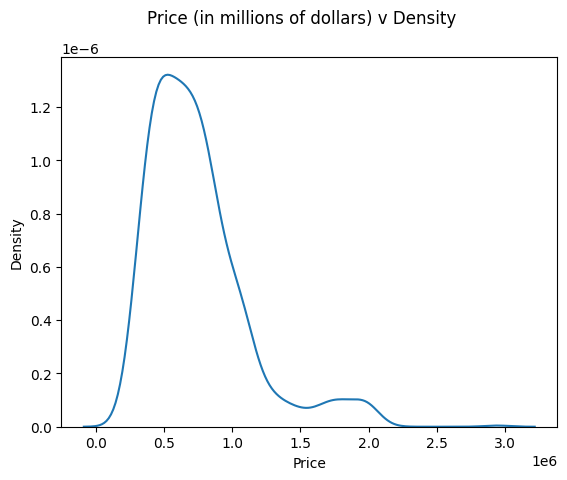

In [24]:
# price kdeplot 

sns.kdeplot(cars['Price'])
plt.suptitle("Price (in millions of dollars) v Density")

plt.show()

In [25]:
# summarize prices by body type
cars.groupby('Body_Type')['Price'].describe()


,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


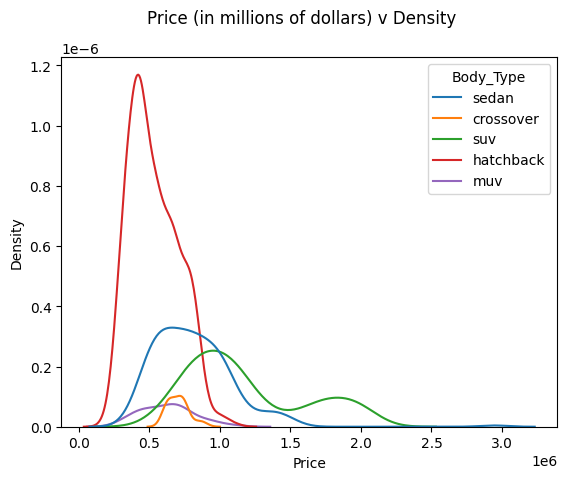

In [26]:
# kde plot by body type

sns.kdeplot(data=cars, x='Price', hue='Body_Type')
plt.suptitle("Price (in millions of dollars) v Density")

plt.show()

**Which car types are the most expensive?**

The car types with the highest mean price are SUVs, sedans, and (to a lesser extent) crossovers.

**Which car types have the most variance?**

The car types with the largest standard deviations are SUVs and sedans.

  **2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?**

In [27]:
#regress price on seating capacity
x = cars[['Seating_Capacity']]
y = cars['Price']

model = LinearRegression()
model = model.fit(x, y)

print(f"Slope Coefficient: {model.coef_}")

Slope Coefficient: [59267.99803672]


The slope coefficient is 59267.998, meaning that for every additional seat in a car, its price increases by ~$59268. 

Slope Coefficients: [np.float64(546483.8709677372), np.float64(1455999.9999999981), np.float64(735948.7179487161), np.float64(271799.999999998)]


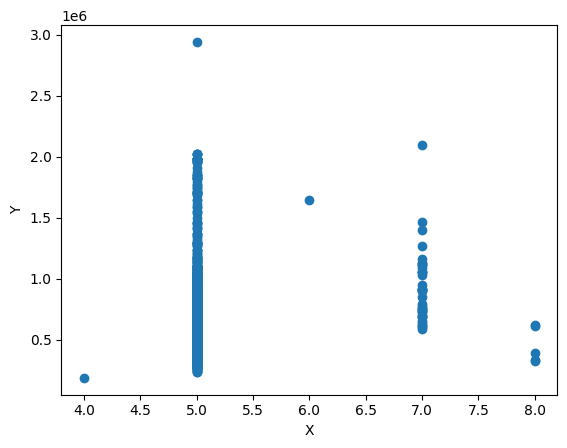

In [28]:
# one hot encoded regress
x_seat = pd.get_dummies(cars['Seating_Capacity'], dtype='int', drop_first=True)
model = LinearRegression()
model = model.fit(x_seat, y)

print(f"Slope Coefficients: {list(model.coef_)}") # made it a list so it would be easier to see the actual values 

# (also plotting data so it's easier for me to see the true relationship)
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

The differences in price are not roughly linear with the number of seats. For that sort of relationship to exist, the price should increase/decrease by the same amount for each additional seat. Our slope coefficients give us information about average price minus our intercept, and we can tell that as number of seats increases, there is at first a sharp increase, and then the price decreases. So, the differences in price are not roughly linear with the number of seats. 

**3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.**

In [29]:
# create new variable
cars['Age'] = 2026 - cars['Make_Year']

#10-fold cross validation
X = cars[['Age']]
model = LinearRegression()
model = model.fit(X, y)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) 

scores = cross_val_score( 
    model,X,y, 
    cv=kfold, 
    scoring='neg_mean_squared_error' 
)

scores = -scores

print("Fold scores:", scores, '\n')
print("Mean score:", np.mean(scores), '\n')
print("Median score:", np.median(scores), '\n')
print("Std dev:", np.std(scores))

Fold scores: [9.05629877e+10 1.04590149e+11 8.35150173e+10 9.42889896e+10
 9.57961145e+10 8.23002081e+10 1.29209046e+11 1.10209665e+11
 7.53798399e+10 1.10087901e+11] 

Mean score: 97593991873.84819 

Median score: 95042552057.2941 

Std dev: 15339123765.102114


  **4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?**

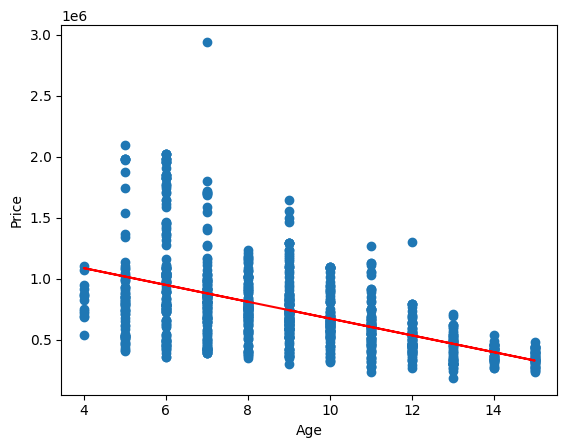

In [31]:
y_hat = model.predict(X)

plt.scatter(X,y) # plot price against age
plt.plot(X,y_hat, 'r') # plot model-predicted price against age
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

The model seems to accurately reflect the broader patterns in the data!

### **Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

In [32]:
heart = pd.read_csv('./data/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


**1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?**

In [33]:
a = heart[heart['transplant']=='control']['y'].mean()
b = heart[heart['transplant']=='treatment']['y'].mean()
ATE = b - a

print("a = ", a)
print("b = ", b)
print("ATE = ", ATE)

a =  0.11764705882352941
b =  0.34782608695652173
ATE =  0.23017902813299232


The ATE on three-year survival for heart transplant interventions is 0.23, so better outcomes than no treatment.

**2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.**

In [34]:
from sklearn.preprocessing import LabelEncoder # to convert string values to binary numeric values in transplant column
le = LabelEncoder()
heart['transplant_num'] = le.fit_transform(heart['transplant'])

x = heart[['transplant_num']]
y = heart['y']

model = LinearRegression()
model = model.fit(x,y)

print(f"Intercept: {model.intercept_}")
print(f"Slope Coefficient: {model.coef_}")

Intercept: 0.11764705882352941
Slope Coefficient: [0.23017903]


The intercept is equivalent to the value we computed for 'a' and the slope coefficient is equivalent to the ATE value.

**3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?**

In [35]:
# regress y on transplant and age
x = heart[['transplant_num', 'age']]

model = LinearRegression()
model = model.fit(x,y)

print(f"Intercept: {model.intercept_}")
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Intercept: 0.7019569721740947


,variable,coefficient
0,transplant_num,0.264702
1,age,-0.013607


The coefficient on transplant increases from 0.230 to 0.264 when we control for age.

The slope for `transplant_num` represents the average change (in this case, increase) in survival when moving from 0 (no transplant) to 1 (transplant). The slope for `age` represents the change in survival as age increases by 1. The intercept represents the survival chance of someone at 0 years of age who did not receive a transplant.

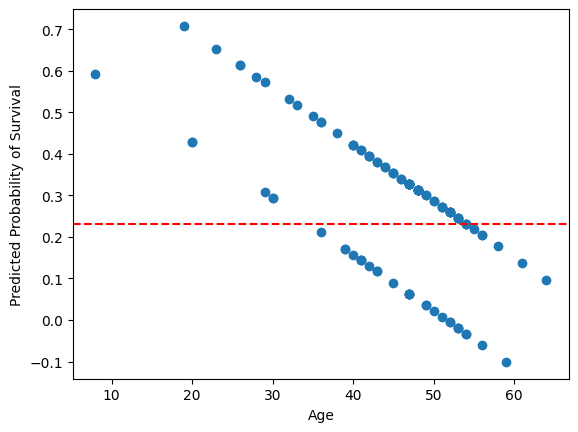

In [36]:
# plot predicted probability of survival by age
y_hat = model.predict(x)

plt.scatter(heart['age'],y_hat) 
plt.axhline(y=ATE,color='r', ls='--')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.show()


The ATE underestimates impact for younger ages (<30) and overestimates for older ages (55+).

**4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?**

In [53]:
# include more controls
heart['age_transplant_interaction'] = heart['transplant_num'] * heart['age']

x = heart[['transplant_num', 'age', 'age_transplant_interaction']]

model = LinearRegression()
model = model.fit(x,y)

print(f"Intercept: {model.intercept_}")
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Intercept: 0.35486517529945905


,variable,coefficient
0,transplant_num,0.907751
1,age,-0.005524
2,age_transplant_interaction,-0.014591


Introducing the age_transplant_interaction variable as a control leads to our transplant coefficient greatly increasing, from 0.265 to 0.907. So, when we control for age and the way that age interacts with transplants, we would predict that receiving a transplant is more likely to result in survival.

**5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.**

In [54]:
# define models
model_1 = model.fit(heart[['transplant_num']],y)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) 

scores = cross_val_score( 
    model_1,heart[['transplant_num']],y, 
    cv=kfold, 
    scoring='neg_mean_squared_error' 
)

scores=-scores

print('Q2 Model')
print("Fold scores:", scores, '\n')
print("Mean score:", np.mean(scores), '\n')
print("Median score:", np.median(scores), '\n')
print("Std dev:", np.std(scores))

Q2 Model
Fold scores: [0.18821929 0.09540463 0.25155303 0.18834547 0.27505257 0.17580257
 0.23480257 0.20624315 0.09155851 0.22965661] 

Mean score: 0.19366383979017968 

Median score: 0.1972943112160721 

Std dev: 0.05794714989607307


In [55]:
model_2 = model.fit(heart[['transplant_num', 'age']],y)

scores = cross_val_score( 
    model_2,heart[['transplant_num', 'age']],y, 
    cv=kfold, 
    scoring='neg_mean_squared_error' 
)

scores=-scores

print('Q3 Model')
print("Fold scores:", scores, '\n')
print("Mean score:", np.mean(scores), '\n')
print("Median score:", np.median(scores), '\n')
print("Std dev:", np.std(scores))

Q3 Model
Fold scores: [0.13199021 0.09724379 0.23532537 0.17986301 0.26846931 0.13026885
 0.15561234 0.21528362 0.17469232 0.22844789] 

Mean score: 0.18171967184387974 

Median score: 0.17727766476646972 

Std dev: 0.05167198499924281


In [56]:
model_3 = model.fit(heart[['transplant_num', 'age', 'age_transplant_interaction']], y)

scores = cross_val_score( 
    model_3,heart[['transplant_num', 'age', 'age_transplant_interaction']],y, 
    cv=kfold, 
    scoring='neg_mean_squared_error' 
)

scores=-scores

print('Q4 Model')
print("Fold scores:", scores, '\n')
print("Mean score:", np.mean(scores), '\n')
print("Median score:", np.median(scores), '\n')
print("Std dev:", np.std(scores))

Q4 Model
Fold scores: [0.13045006 0.09902894 0.233215   0.25380574 0.27583732 0.11557048
 0.12649585 0.20870022 0.14792529 0.21568012] 

Mean score: 0.1806709027296536 

Median score: 0.1783127547071696 

Std dev: 0.06050647919386986


**6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?**

The main concern I would have is that this model doesn't seem to capture all of the trends in the data. Looking at every residual plot (below), each model produces linear relationships in the residual plot, where lower predicted values correspond to positive residuals and higher predicted values correspond to negative residuals. This indicates that a linear model isn't appropriate for this data and is missing something like curvature. So, my main concern would be that it wouldn't correctly prioritize transplant access according to the actual trends in the data we have. 

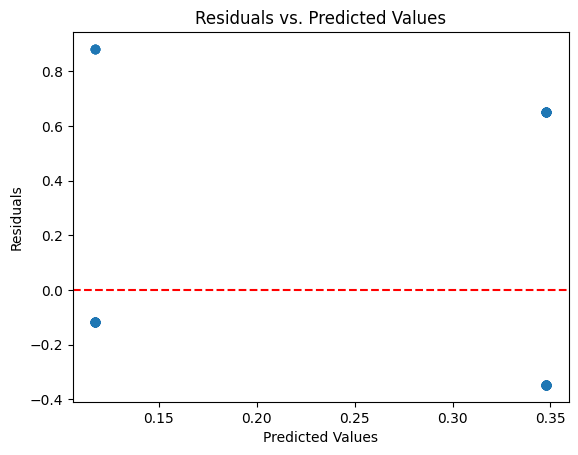

In [57]:
model_1 = model.fit(heart[['transplant_num']],y)
y_pred1 = model_1.predict(heart[['transplant_num']])
residuals1 = y - y_pred1

# 2. Plot Residuals vs Predicted
plt.scatter(y_pred1, residuals1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

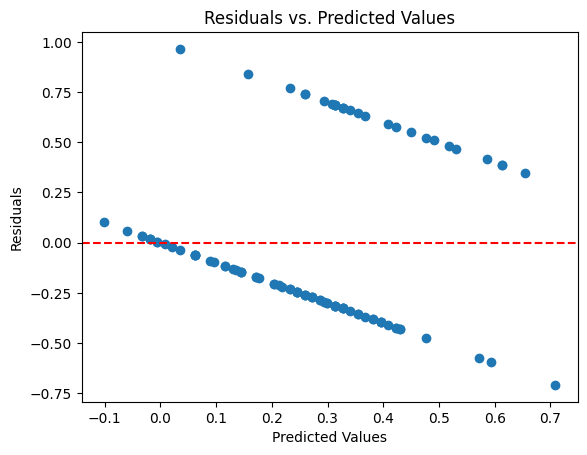

In [58]:
model_2 = model.fit(heart[['transplant_num', 'age']],y) #idk why but if i don't define them again they want every input?
y_pred2 = model_2.predict(heart[['transplant_num','age']])
residuals2 = y - y_pred2

# 2. Plot Residuals vs Predicted
plt.scatter(y_pred2, residuals2)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

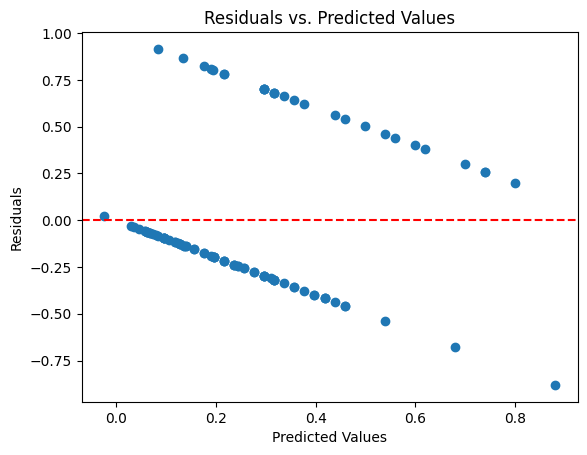

In [59]:
model_3 = model.fit(heart[['transplant_num', 'age', 'age_transplant_interaction']], y)
y_pred3 = model_3.predict(heart[['transplant_num', 'age', 'age_transplant_interaction']])
residuals3 = y - y_pred3

# 2. Plot Residuals vs Predicted
plt.scatter(y_pred3, residuals3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()